In [2]:
# Imports and settings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

BUSINESS_PATH  = 'business_cards_MDQ.parquet'
CONSUMER_PATH  = 'consumer_cards_MDQ.parquet'
MERCHANTS_PATH = 'merchants_reference.parquet'

In [3]:
#1 Loading data
df_biz = pd.read_parquet(BUSINESS_PATH)
df_con = pd.read_parquet(CONSUMER_PATH)
df_merchants = pd.read_parquet(MERCHANTS_PATH)
df_biz.rename(columns={'Is_recurring': 'is_recurring'}, inplace=True)
df_con.rename(columns={'Is_recurring': 'is_recurring'}, inplace=True)

# '1'-commercial  '0'-personal
df_biz['label'] = 1
df_con['label'] = 0

print(f'Business Cards: {df_biz["card_number"].nunique():,} cards and {len(df_biz):,} transactions')
print(f'Consumer Cards: {df_con["card_number"].nunique():,} cards and {len(df_con):,} transactions')
print(f'Merchants: {len(df_merchants):,} records')

df_all = pd.concat([df_biz, df_con], ignore_index=True)
df_all['transaction_date'] = pd.to_datetime(df_all['transaction_date'])
df_all['transaction_timestamp'] = pd.to_datetime(df_all['transaction_timestamp'])
df_all = df_all.merge(df_merchants[['merchant_id', 'merchant_name', 'merchant_country', 'recurring_capable']], on='merchant_id', how='left')

Business Cards: 25,000 cards and 2,997,593 transactions
Consumer Cards: 80,000 cards and 9,832,487 transactions
Merchants: 2,165 records


In [5]:
#2 cleaning
df_all = df_all[df_all['transaction_amount_kzt'] > 0].copy()
df_all['merchant_country']  = df_all['merchant_country'].fillna('Unknown')
df_all['recurring_capable'] = df_all['recurring_capable'].fillna(False)

In [7]:
#3 EDA
df_all['hour'] = df_all['transaction_timestamp'].dt.hour
df_all['day_of_week'] = df_all['transaction_timestamp'].dt.dayofweek

eda_summary = df_all.groupby('label').agg(
    avg_amount=('transaction_amount_kzt', 'mean'),
    median_amount=('transaction_amount_kzt', 'median'),
    unique_merchants=('merchant_id', 'nunique'),
    unique_mccs=('mcc', 'nunique'),
    pct_offline=('channel', lambda x: (x == 'offline').mean()),
    total_txns=('transaction_amount_kzt', 'count'),
).rename(index={0: 'personal (0)', 1: 'commercial (1)'})
#display(eda_summary.T)

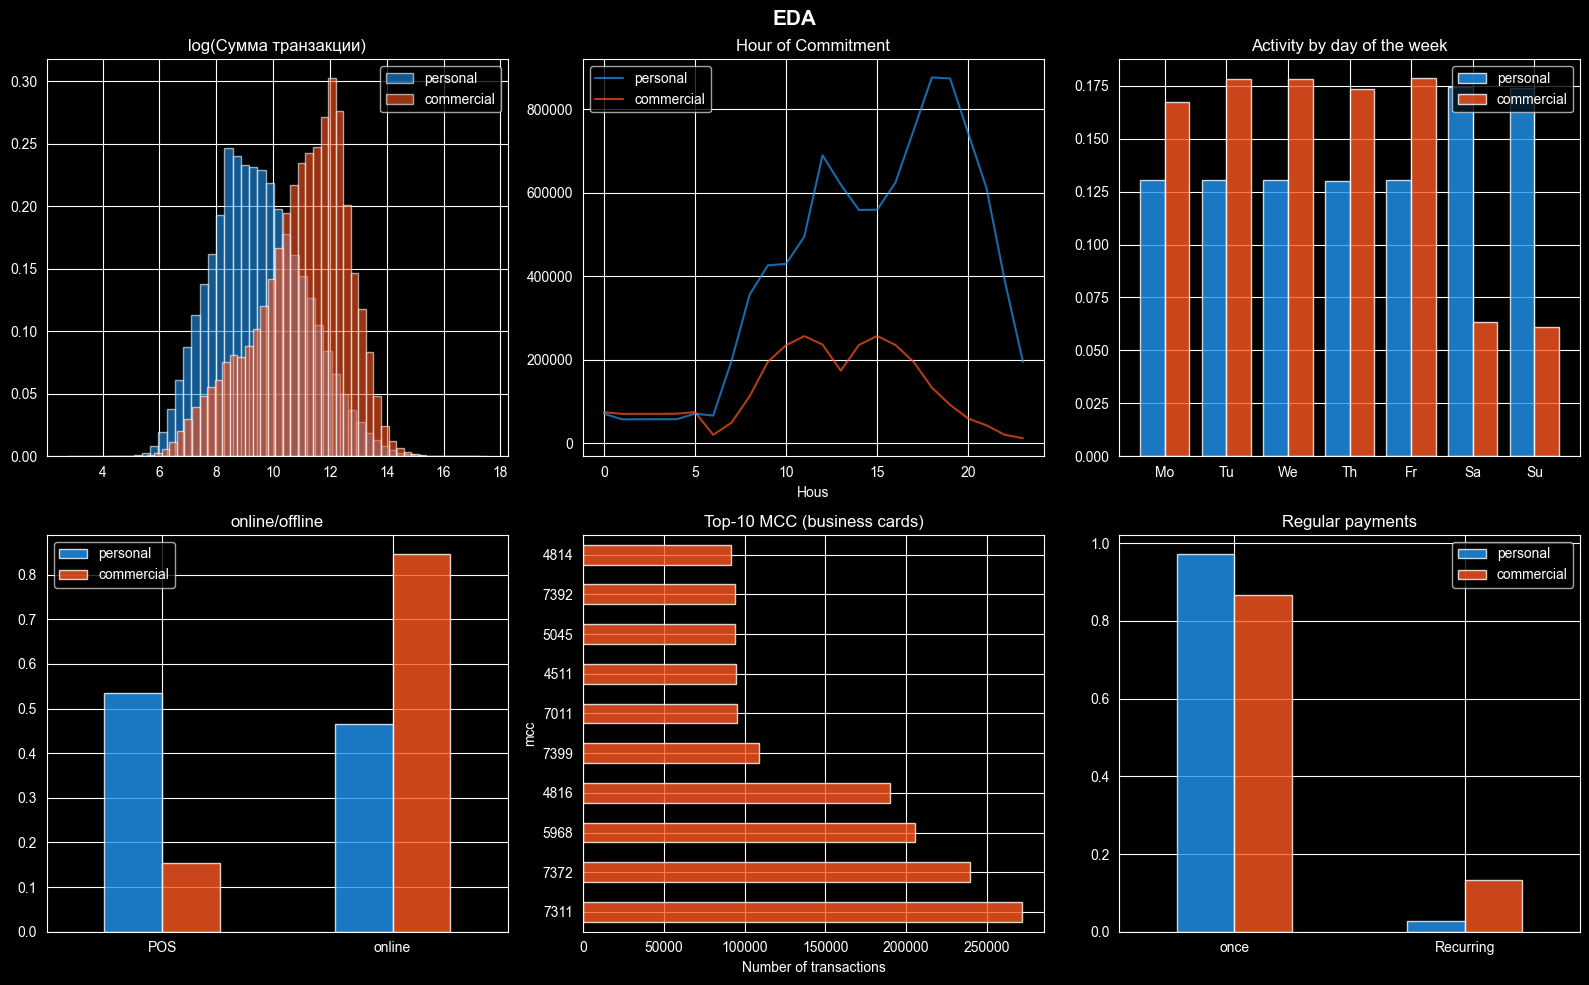

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('EDA', fontsize=15, fontweight='bold')

biz = df_all[df_all['label'] == 1]
con = df_all[df_all['label'] == 0]

# distribution of amounts
ax = axes[0, 0]
ax.hist(np.log1p(con['transaction_amount_kzt']), bins=50, alpha=0.6,
        label='personal', color='#2196F3', density=True)
ax.hist(np.log1p(biz['transaction_amount_kzt']), bins=50, alpha=0.6,
        label='commercial', color='#FF5722', density=True)
ax.set_title('log(Сумма транзакции)')
ax.legend()

# Hour of Commitment
ax = axes[0, 1]
con['hour'].value_counts().sort_index().plot(ax=ax, label='personal',color='#2196F3', alpha=0.7)
biz['hour'].value_counts().sort_index().plot(ax=ax, label='commercial',color='#FF5722', alpha=0.7)
ax.set_title('Hour of Commitment')
ax.set_xlabel('Hous')
ax.legend()

# day of the week
ax = axes[0, 2]
days = ['Mo','Tu','We','Th','Fr','Sa','Su']
con_dow = con['day_of_week'].value_counts().sort_index() / len(con)
biz_dow = biz['day_of_week'].value_counts().sort_index() / len(biz)
x = np.arange(7)
ax.bar(x - 0.2, con_dow, 0.4, label='personal', color='#2196F3', alpha=0.8)
ax.bar(x + 0.2, biz_dow, 0.4, label='commercial', color='#FF5722', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(days)
ax.set_title('Activity by day of the week')
ax.legend()

# online/offline
ax = axes[1, 0]
channel_data = pd.DataFrame({'personal': con['channel'].value_counts(normalize=True), 'commercial': biz['channel'].value_counts(normalize=True),})
channel_data.plot(kind='bar', ax=ax, color=['#2196F3', '#FF5722'], alpha=0.8)
ax.set_title('online/offline')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)

# 5. top MCC
ax = axes[1, 1]
top_mcc_biz = biz['mcc'].value_counts().head(10)
top_mcc_biz.plot(kind='barh', ax=ax, color='#FF5722', alpha=0.8)
ax.set_title('Top-10 MCC (business cards)')
ax.set_xlabel('Number of transactions')

# share recurring
ax = axes[1, 2]
rec_data = pd.DataFrame({'personal': con['is_recurring'].value_counts(normalize=True), 'commercial': biz['is_recurring'].value_counts(normalize=True),})
rec_data.rename(index={True: 'Recurring', False: 'once'}).plot(kind='bar', ax=ax, color=['#2196F3', '#FF5722'], alpha=0.8)
ax.set_title('Regular payments')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()